# Imports

In [1]:
from model_builder import ModelBuilder
from model_utils import *
import random
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import colorsys
from sklearn.decomposition import PCA
plt.rcParams["font.family"] = "Times New Roman"
import warnings
warnings.filterwarnings("ignore")

In [2]:
with open("config.json", "rb") as json_file:
    config = json.load(json_file)
config

{'becker': {'filename': 'beckerestimation_output_conversation_level.csv',
  'cols_to_ignore': ['conversation_num',
   'mean_pre_discussion_error',
   'mean_post_discussion_error',
   'median_pre_discussion_error',
   'median_post_discussion_error',
   'median_pre_discussion_error_pct',
   'median_post_discussion_error_pct',
   'mean_pre_discussion_error_pct',
   'mean_post_discussion_error_pct',
   'reverse_mean_post_discussion_error_pct',
   'reverse_median_post_discussion_error_pct',
   'question',
   'chatrooms',
   'trial_indx']},
 'csop': {'filename': 'csop_output_conversation_level.csv',
  'cols_to_ignore': ['conversation_num',
   'batch_num',
   'round_num',
   'round_index',
   'task_index',
   'complexity',
   'type',
   'social_perceptiveness',
   'skill',
   'normalized_score',
   'score',
   'duration',
   'efficiency']},
 'csopII': {'filename': 'csopII_output_conversation_level.csv',
  'cols_to_ignore': ['conversation_num',
   'batch_num',
   'vis_img',
   'int_verb',
   '

# Jury

In [3]:
# Define the basic model
juries_model = ModelBuilder(dataset_names = ["juries"])
juries_model.select_target(target=["majority_pct"])
juries_model.define_model(model_type = 'rf')

# CSOP (blended)

In [4]:
csop_blended_model = ModelBuilder(dataset_names = ["csop", "csopII"])
csop_blended_model.select_target(target=["efficiency", "efficiency"])
csop_blended_model.define_model(model_type = 'rf')

# DAT

In [5]:
dat_model = ModelBuilder(dataset_names = ["dat"])
dat_model.select_target(target=["efficiency"])
dat_model.define_model(model_type = 'rf')

# Estimation

In [6]:
estimation_blended_model = ModelBuilder(dataset_names = ["gurcay", "becker"])
estimation_blended_model.select_target(target=["mean_post_discussion_error_pct", "mean_post_discussion_error_pct"])
estimation_blended_model.define_model(model_type = 'rf')

# Create a PCA plot of the conversation features, colored by task

In [7]:
juries_data = pd.read_csv('../output/jury_output_conversation_level.csv')
csop_data = pd.read_csv('../output/csop_output_conversation_level.csv')
csopII_data = pd.read_csv('../output/csopII_output_conversation_level.csv')
dat_data = pd.read_csv('../output/dat_output_conversation_level.csv')
becker_data = pd.read_csv('../output/beckerestimation_output_conversation_level.csv')
gurcay_data = pd.read_csv('../output/gurcay2015estimation_output_conversation_level.csv')

In [8]:
juries_data, csop_data, csopII_data, dat_data, becker_data, gurcay_data = drop_non_common_columns([juries_data, csop_data, csopII_data, dat_data, becker_data, gurcay_data])

csop_blended_data = pd.concat([csop_data,csopII_data], axis=0)
estimation_blended_data = pd.concat([becker_data,gurcay_data], axis=0)

In [9]:
juries_data, csop_blended_data, dat_data, estimation_blended_data = get_numeric_cols([juries_data, csop_blended_data, dat_data, estimation_blended_data])

In [10]:
juries_data, csop_blended_data, csop_data, csopII_data, dat_data, estimation_blended_data, becker_data, gurcay_data = get_convs_with_min_value([juries_data, csop_blended_data, csop_data, csopII_data, dat_data, estimation_blended_data, becker_data, gurcay_data], "sum_num_messages", 10)

# PCA of Datasets

How do people "speak differently" across different tasks? Can we identify these different patterns of speaking just through clustering each conversation?

In [11]:
labels = ["Mock Jury", "Room Assignment Task", "Divergent Association Task", "Estimation"]
dataset_labels = ["Mock Jury", "CSOP", "CSOPII", "DAT", "Estimation (Becker)", "Estimation (Gurcay)"]

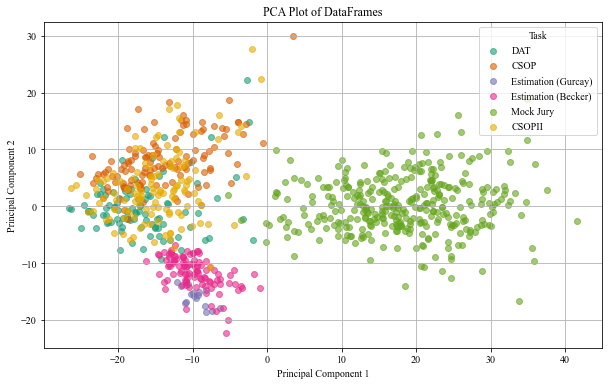

In [12]:
pca_results = plot_pca_of_dataframes(juries_data, csop_data, csopII_data, dat_data, becker_data, gurcay_data, labels=dataset_labels, title = "PCA Scatter Plot of Conversations (By Dataset)")

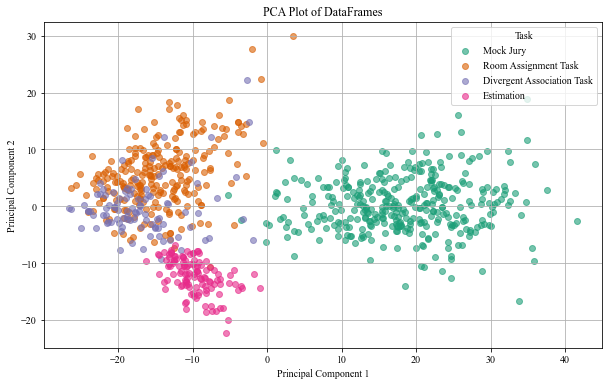

In [13]:
pca_results = plot_pca_of_dataframes(juries_data, csop_blended_data, dat_data, estimation_blended_data, labels=labels, title = "PCA Scatter Plot of DataFrames (By Task)")

In [14]:
pca_results.explained_variance_ratio_

array([0.2831507, 0.0547003])

In [15]:
examine_top_n_components(pca_results, n=10)

Top 5 Features for PC1:
                                      Feature       PC1       PC2   PC1_abs  \
160                average_user_avg_num_chars  0.055270 -0.003036  0.055270   
879   average_user_avg_nltk_english_stopwords  0.055269  0.000405  0.055269   
252                average_user_avg_num_words  0.055257 -0.001247  0.055257   
773            average_nltk_english_stopwords  0.055113  0.001155  0.055113   
744                         average_num_chars  0.055105 -0.002558  0.055105   
979                         average_num_words  0.055071 -0.000526  0.055071   
951                average_user_sum_num_chars  0.054864  0.034962  0.054864   
519   average_user_sum_nltk_english_stopwords  0.054745  0.034887  0.054745   
215           average_user_avg_cognitive_mech  0.054600 -0.001224  0.054600   
1019                   average_user_avg_verbs  0.054541  0.000520  0.054541   

       PC2_abs  
160   0.003036  
879   0.000405  
252   0.001247  
773   0.001155  
744   0.002558  
979 

,Feature,PC1,PC2,PC1_abs,PC2_abs
0,min_user_sum_verbs,0.042290,0.057217,0.042290,0.057217
1,min_user_avg_article,0.042155,0.019452,0.042155,0.019452
2,stdev_see,-0.012357,0.033916,0.012357,0.033916
3,stdev_2nd_person_start,0.003837,0.015344,0.003837,0.015344
4,min_user_sum_indirect_(greeting),-0.002138,0.009745,0.002138,0.009745
...,...,...,...,...,...
1034,min_user_avg_first_person_plural,-0.005822,0.039811,0.005822,0.039811
1035,min_user_avg_first_pronouns_proportion,0.010450,0.055129,0.010450,0.055129
1036,stdev_user_sum_1st_person_pl.,-0.009244,0.048523,0.009244,0.048523
1037,average_user_avg_work,0.030058,-0.006976,0.030058,0.006976


PC 1 mostly captures *the quantity of how much people talk*.

PC 2 captures a combination of ideas: Type-Token Ratio, Number of Messages, Subjectivity, Positivity.

In general, Juries talk the most > Estimation second > CSOP / DAT last.

In general, Estimation has a lower PC2 (lower type/token ratio, lower positivity...)

## How much do all the other PC's tell us?
Answer: not a ton...

In [16]:
full_pca = get_pca_of_dataframes([juries_data, csop_blended_data, dat_data, estimation_blended_data], n_components = 10)

([<matplotlib.axis.XTick at 0x1429b6c70>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9')])

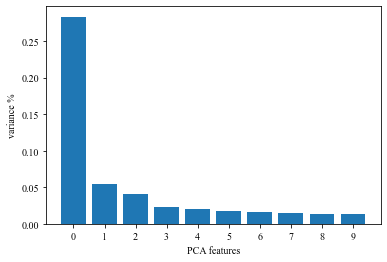

In [17]:
var = full_pca.explained_variance_ratio_
plt.bar(list(range(var.shape[0])),var)
feature = range(full_pca.n_components_)
plt.xlabel('PCA features')
plt.ylabel('variance %')
plt.xticks(feature)

# PCA of Features

Can we now model each feature as a point, and see how the different features relate to each other?

(The following code generates an interactive PCA plot, but opens in a brower window.)

Columns with NaN values: ['min_user_avg_direct_question', 'min_quantifier', 'min_user_avg_body', 'min_1st_person_start', 'min_apologizing', 'min_anxiety', 'max_indirect_(btw)', 'min_see', 'max_user_sum_indirect_(btw)', 'stdev_indirect_(btw)', 'min_num_question_naive', 'min_user_avg_indicative', 'min_relative', 'min_function_word_accommodation', 'min_sadness', 'min_swear', 'average_indirect_(btw)', 'min_user_sum_death', 'max_haspositive', 'min_user_avg_religion', 'min_user_avg_sexual', 'max_word_TTR', 'min_subjunctive', 'min_user_avg_indirect_(btw)', 'stdev_num_messages', 'min_conjunction', 'min_user_sum_indicative', 'min_health', 'stdev_user_avg_indirect_(btw)', 'min_hedge_naive', 'min_hear', 'min_hedge_words', 'min_friends', 'min_home', 'max_num_messages', 'min_religion', 'min_direct_question', 'min_deference', 'min_indefinite_pronoun', 'min_direct_start', 'min_indicative', 'min_first_person_plural', 'min_indirect_(btw)', 'min_user_sum_NTRI', 'min_exclusive', 'min_article', 'min_pleas

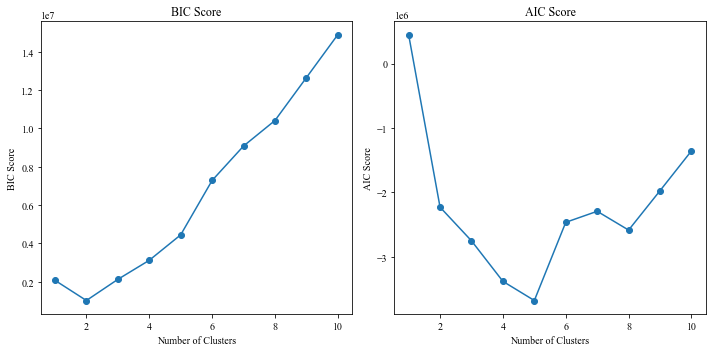

In [18]:
visualize_feature_clusters([juries_data, csop_blended_data, dat_data, estimation_blended_data], use_aic = True, title = "PCA Scatter Plot of Conversational Features")

## PCA of User Features

In [19]:
jury_users = pd.read_csv('../output/jury_output_user_level.csv')
csop_users = pd.read_csv('../output/csop_output_user_level.csv')
csopII_users = pd.read_csv('../output/csopII_output_user_level.csv')
dat_users = pd.read_csv('../output/dat_output_user_level.csv')
becker_estimation_users = pd.read_csv('../output/beckerestimation_output_user_level.csv')
gurcay_estimation_users = pd.read_csv('../output/gurcay2015estimation_output_user_level.csv')

In [20]:
# Get Non-Empty Conversations
jury_users, csop_users, csopII_users, dat_users, becker_estimation_users, gurcay_estimation_users = get_users_in_nonempty_conversations([jury_users, csop_users, csopII_users, dat_users, becker_estimation_users, gurcay_estimation_users])

In [21]:
# Preprocess the user dataframes
jury_users, csop_users, csopII_users, dat_users, becker_estimation_users, gurcay_estimation_users = drop_non_common_columns([jury_users, csop_users, csopII_users, dat_users, becker_estimation_users, gurcay_estimation_users])

csop_blended_users = pd.concat([csop_users,csopII_users], axis=0)
estimation_blended_users = pd.concat([becker_estimation_users,gurcay_estimation_users], axis=0)

# Then get only the numeric columns
jury_users, csop_blended_users, dat_users, estimation_blended_users = get_numeric_cols([jury_users, csop_blended_users, dat_users, estimation_blended_users])

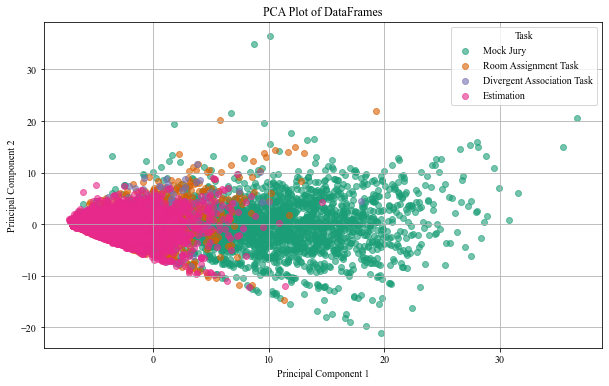

In [22]:
pca_results_users = plot_pca_of_dataframes(jury_users, csop_blended_users, dat_users, estimation_blended_users, labels=labels, title = "PCA Scatter Plot of Users (By Task)")

In [23]:
pca_results_users.explained_variance_ratio_

array([0.26327829, 0.05470521])

In [24]:
examine_top_n_components(pca_results_users, n=10)

Top 5 Features for PC1:
                        Feature       PC1       PC2   PC1_abs   PC2_abs
102  sum_nltk_english_stopwords  0.136225  0.061513  0.136225  0.061513
9                 sum_num_chars  0.136074  0.070750  0.136074  0.070750
2                 sum_num_words  0.135995  0.077420  0.135995  0.077420
57           sum_cognitive_mech  0.134440  0.057344  0.134440  0.057344
132                   sum_verbs  0.133991  0.060913  0.133991  0.060913
29          sum_auxiliary_verbs  0.131312  0.058548  0.131312  0.058548
10                   sum_social  0.127877  0.046320  0.127877  0.046320
109           sum_present_tense  0.127853  0.069428  0.127853  0.069428
115             sum_preposition  0.126775  0.046809  0.126775  0.046809
156           average_num_words  0.124728 -0.133995  0.124728  0.133995

Top 5 Features for PC2:
                                Feature       PC1       PC2   PC1_abs  \
56                         sum_word_TTR  0.071218  0.233086  0.071218   
146          

,Feature,PC1,PC2,PC1_abs,PC2_abs
0,average_indicative,0.002068,0.000144,0.002068,0.000144
1,sum_past_tense,0.091644,0.041542,0.091644,0.041542
2,sum_num_words,0.135995,0.077420,0.135995,0.077420
3,sum_subjunctive,0.008496,0.017569,0.008496,0.017569
4,average_home,0.039663,-0.043685,0.039663,0.043685
...,...,...,...,...,...
182,average_gratitude,-0.001588,0.014470,0.001588,0.014470
183,sum_humans,0.070797,0.039550,0.070797,0.039550
184,sum_health,0.026430,0.019738,0.026430,0.019738
185,sum_indirect_(greeting),0.000439,0.055952,0.000439,0.055952
